### Log-Likelihood Visualize

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def normal_pdf(x, mu, sigma):
    """Calculates the individual probability density f(x | mu, sigma)"""
    return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

In [3]:
def compute_log_likelihood(mu_candidate, data, sigma):
    """
    Calculates ln L(mu | x) using sum of log-densities.
    This prevents numerical underflow when sample size n is large.
    """
    log_pdfs = -0.5 * np.log(2 * np.pi * sigma**2) - 0.5 * ((data - mu_candidate) / sigma)**2
    return np.sum(log_pdfs)

In [4]:
# Generate a Large Observed Dataset (n = 500)
n_samples = 500
mu_true = 5.0
sigma = 1.0

np.random.seed(42)
X = np.random.normal(loc=mu_true, scale=sigma, size=n_samples)

mean = np.mean(X)

[]

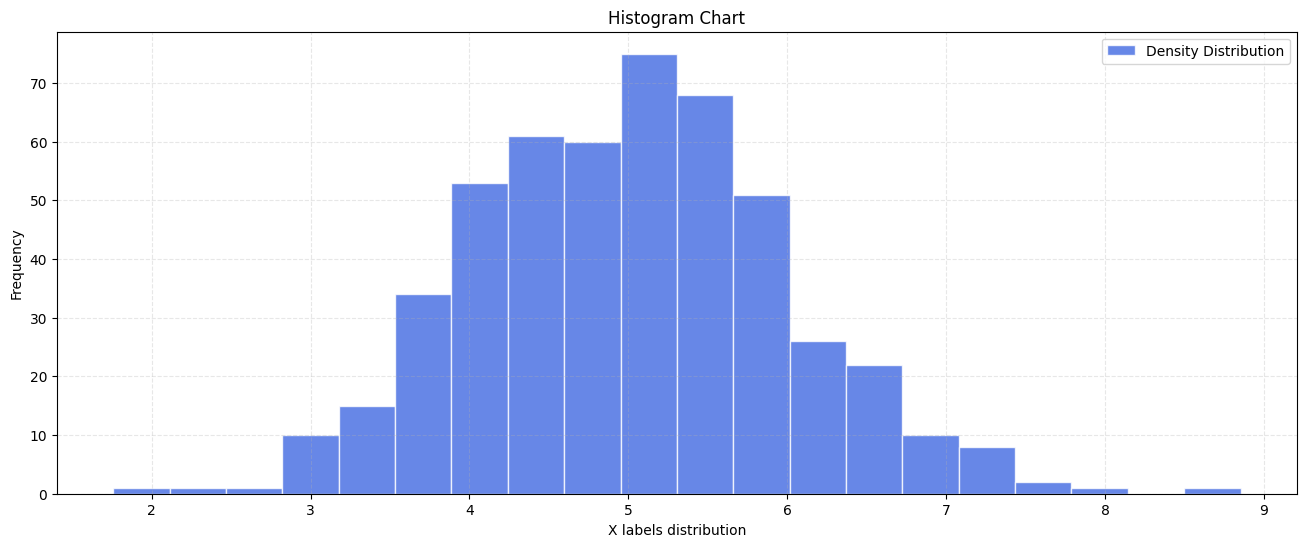

In [5]:
plt.figure(figsize=(16,6))
plt.hist(X, bins=20, color='royalblue', edgecolor='white', alpha=0.8, label='Density Distribution')
plt.title('Histogram Chart')
plt.xlabel('X labels distribution')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.plot()

In [6]:
# Machine Learning Optimization (Gradient Ascent)
epochs = 100
curr_mu = 2.0
learning_rate = 0.0001

history_mu = [curr_mu]

In [7]:
def compute_gradient(mu, X, sigma):
    return np.sum((X - mu) / sigma**2)

In [8]:
for epoch in range(epochs):
    grad = compute_gradient(curr_mu, X, sigma)
    curr_mu = curr_mu + learning_rate * grad
    history_mu.append(curr_mu)

In [9]:
print(f"Final Optimized Mu after {epochs} epochs: {curr_mu:.4f}")
print(f"Analytical Sample Mean (np.mean(X)) to compare: {np.mean(X):.4f}")

Final Optimized Mu after 100 epochs: 4.9890
Analytical Sample Mean (np.mean(X)) to compare: 5.0068


In [12]:
mu_min, mu_max = min(history_mu) - 0.5, max(history_mu) + 0.5
mu_grid = np.linspace(mu_min, mu_max, 500)
log_likelihood_grid = [compute_log_likelihood(m, X, sigma) for m in mu_grid]
log_likelihood_history = [compute_log_likelihood(m, X, sigma) for m in history_mu]

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_23366/1478889711.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.scatter(history_mu[0], log_likelihood_history[0], color='red', s=150, zorder=5, label=f'Random Init ($\mu$={history_mu[0]})')
/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_23366/1478889711.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.scatter(curr_mu, log_likelihood_grid[-1], color='green', s=150, zorder=5, label=f'Optimized Peak ($\mu$={curr_mu:.4f})')
/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_23366/1478889711.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Parameter $\mu$', fontsize=11)


[]

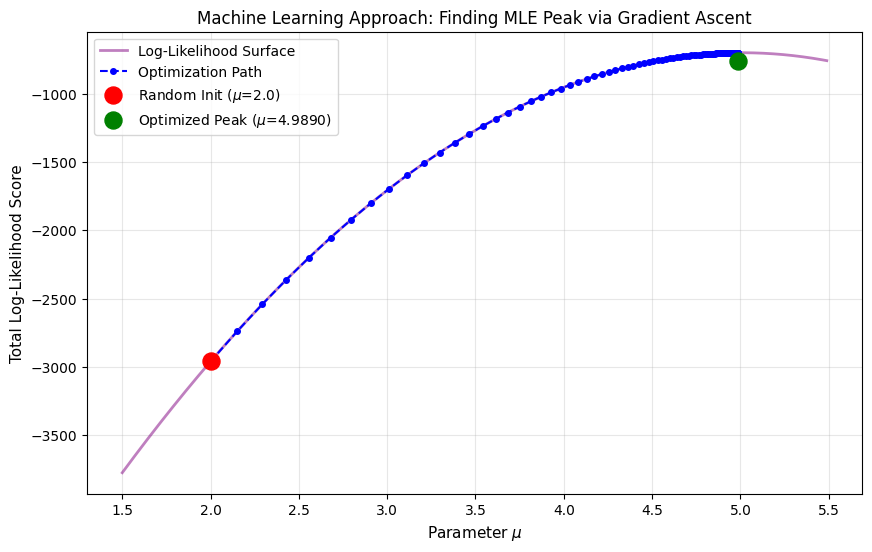

In [16]:
# Pure Visualization of the Optimization Path
plt.figure(figsize=(10,6))
plt.plot(mu_grid, log_likelihood_grid, color='purple', lw=2, alpha=0.5, label='Log-Likelihood Surface')

# Plot the path taken by the Machine Learning algorithm
plt.plot(history_mu, log_likelihood_history, color='blue', linestyle='--', marker='o', markersize=4, label='Optimization Path')

plt.scatter(history_mu[0], log_likelihood_history[0], color='red', s=150, zorder=5, label=f'Random Init ($\mu$={history_mu[0]})')
plt.scatter(curr_mu, log_likelihood_grid[-1], color='green', s=150, zorder=5, label=f'Optimized Peak ($\mu$={curr_mu:.4f})')

plt.title('Machine Learning Approach: Finding MLE Peak via Gradient Ascent', fontsize=12, fontweight=12)
plt.xlabel('Parameter $\mu$', fontsize=11)
plt.ylabel('Total Log-Likelihood Score', fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend()
plt.plot()